<a href="https://colab.research.google.com/github/anuhingankar9922-hub/-Python-Basic-Projects/blob/main/Task19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q2. (Dataset Selection & Initial Exploration) Load the dataset and show first 10 rows. Write 5-6 lines explaining why you chose this dataset and what continuous value you want to predict.

In [2]:
import zipfile
import pandas as pd

with zipfile.ZipFile("/content/archive (4).zip")as z:
 df=pd.read_csv(z.open('output.csv'))

 print(df.head(10))

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   
5  2014-05-02 00:00:00   490000.0       2.0       1.00          880      6380   
6  2014-05-02 00:00:00   335000.0       2.0       2.00         1350      2560   
7  2014-05-02 00:00:00   482000.0       4.0       2.50         2710     35868   
8  2014-05-02 00:00:00   452500.0       3.0       2.50         2430     88426   
9  2014-05-02 00:00:00   640000.0       4.0       2.00         1520      6200   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0  

Q3.( Missing & Duplicate Values Analysis) Check for missing values in each column and calculate their percentage. Handle missing values appropriately (drop or fill). Check and remove duplicate rows if any. Write your observations and steps taken.

In [5]:
print(df.isnull().sum())

missing = (df.isnull().sum()/len(df))*100
print(missing)
df.fillna(df.mean(numeric_only=True), inplace=True)
print("Duplicates:",df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates after removal:",df.duplicated().sum())

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64
date             0.0
price            0.0
bedrooms         0.0
bathrooms        0.0
sqft_living      0.0
sqft_lot         0.0
floors           0.0
waterfront       0.0
view             0.0
condition        0.0
sqft_above       0.0
sqft_basement    0.0
yr_built         0.0
yr_renovated     0.0
street           0.0
city             0.0
statezip         0.0
country          0.0
dtype: float64
Duplicates: 0
Duplicates after removal: 0


Q4. (Statistical Summary) Use describe() to generate statistical summary of numeric columns. Identify min, max, mean, and median of the target variable. Write at least 4 meaningful observations about the data distribution.

In [20]:
print("------------------------->< Statistical Summary ><-------------------------\n")
print(df.describe())
print("---------------------------------------------------------------------------")
print("\nMinimum :", df["price"].min())
print("Maximum :", df["price"].max())
print("Mean :", df["price"].mean())
print("Median :", df["price"].median())

------------------------->< Statistical Summary ><-------------------------

              price     bedrooms    bathrooms   sqft_living      sqft_lot  \
count  4.600000e+03  4600.000000  4600.000000   4600.000000  4.600000e+03   
mean   5.519630e+05     3.400870     2.160815   2139.103478  1.485252e+04   
std    5.638347e+05     0.908848     0.783781    963.159990  3.588444e+04   
min    0.000000e+00     0.000000     0.000000    370.000000  6.380000e+02   
25%    3.228750e+05     3.000000     1.750000   1460.000000  5.000750e+03   
50%    4.609435e+05     3.000000     2.250000   1980.000000  7.683000e+03   
75%    6.549625e+05     4.000000     2.500000   2620.000000  1.100125e+04   
max    2.659000e+07     9.000000     8.000000  13540.000000  1.074218e+06   

            floors   waterfront         view    condition   sqft_above  \
count  4600.000000  4600.000000  4600.000000  4600.000000  4600.000000   
mean      1.512065     0.007174     0.240652     3.451739  1827.265435   
std    

Q5. (Histogram Analysis of Numeric Features) Plot histograms for all important numeric columns (including the target variable). Write detailed insights for each plot.

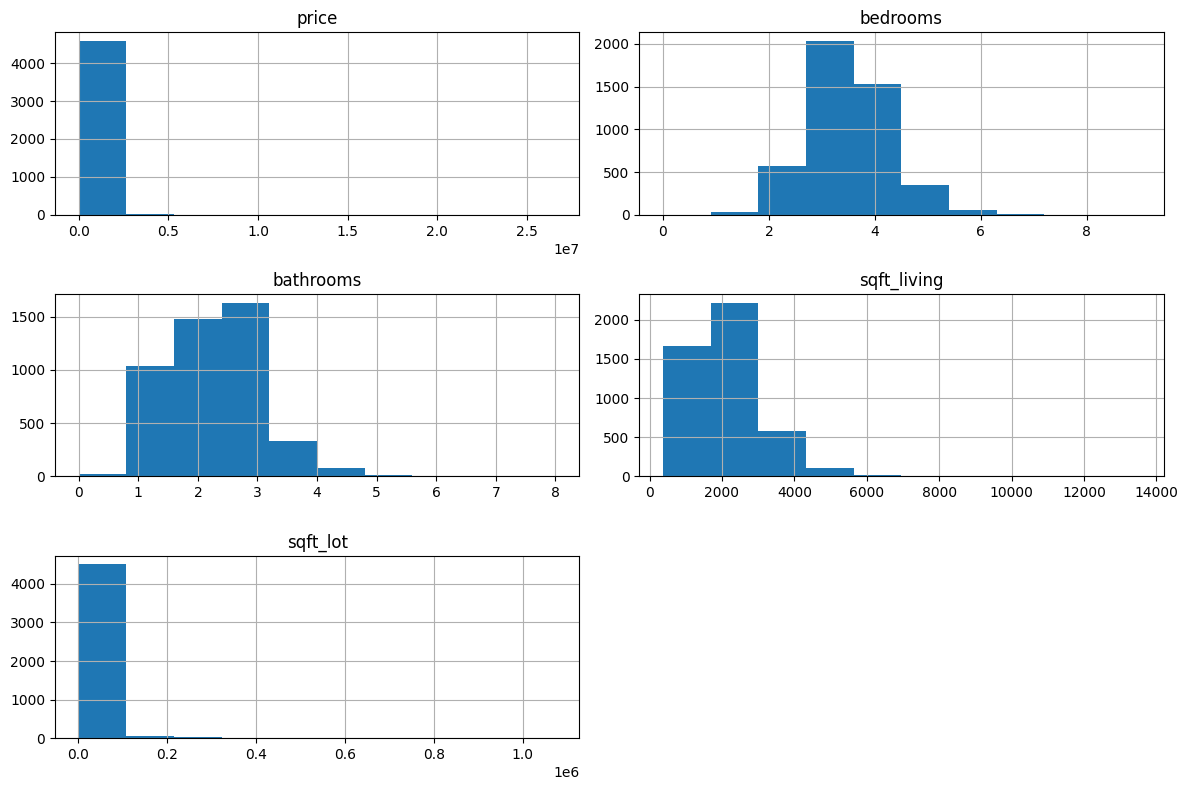

In [21]:
import matplotlib.pyplot as plt

df[["price","bedrooms","bathrooms","sqft_living","sqft_lot"]].hist(figsize=(12,8))

plt.tight_layout()
plt.show()

Q6. (Count Plots of Categorical Features) Identify categorical columns in your dataset. Create count plots for all categorical features using seaborn. Analyze the distribution and write business/domain-related insights.

In [30]:
print("Categorical Columns:-")
print(df.select_dtypes(include="object").columns)

Categorical Columns:-
Index(['date', 'street', 'city', 'statezip', 'country'], dtype='object')



------------------------------------------:Count Plots:-------------------------------------



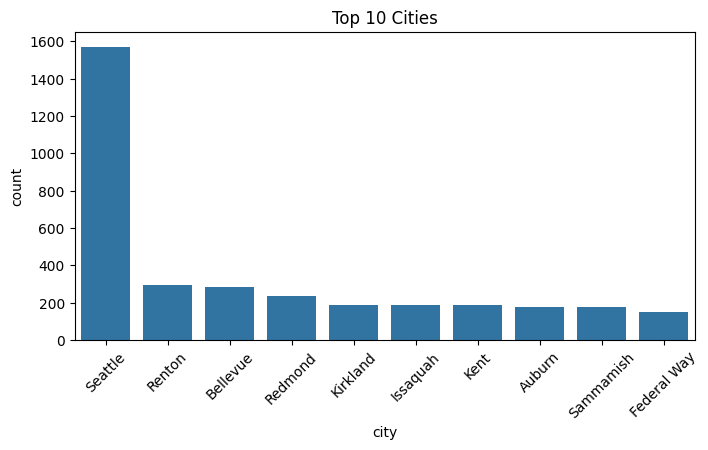

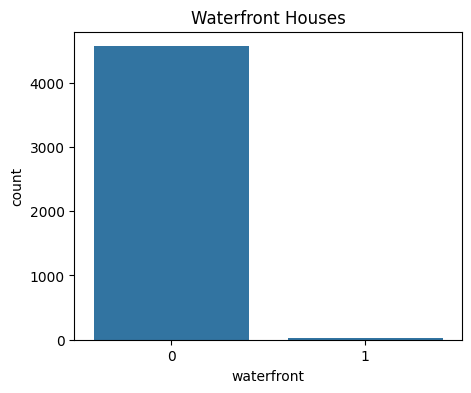

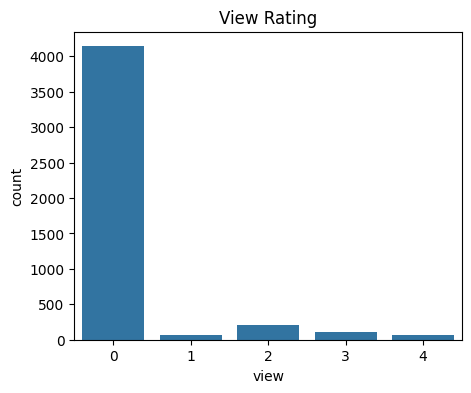

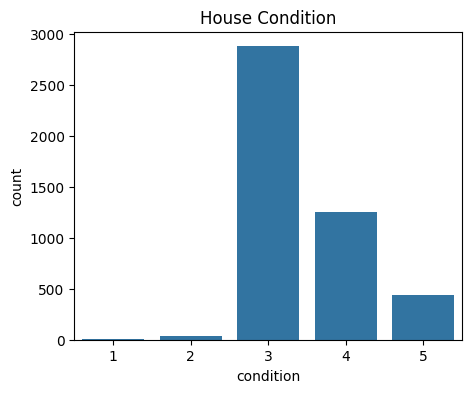

In [39]:
print("\n------------------------------------------:Count Plots:-------------------------------------\n")
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.countplot(x="city", data=df, order=df["city"].value_counts().head(10).index)
plt.xticks(rotation=45)
plt.title("Top 10 Cities")
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(x="waterfront", data=df)
plt.title("Waterfront Houses")
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(x="view", data=df)
plt.title("View Rating")
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(x="condition", data=df)
plt.title("House Condition")
plt.show()

Q7. (Correlation Heatmap) Create a correlation heatmap for all numeric features. Highlight which features are strongly correlated with the target variable. Write your observations regarding feature relationships.

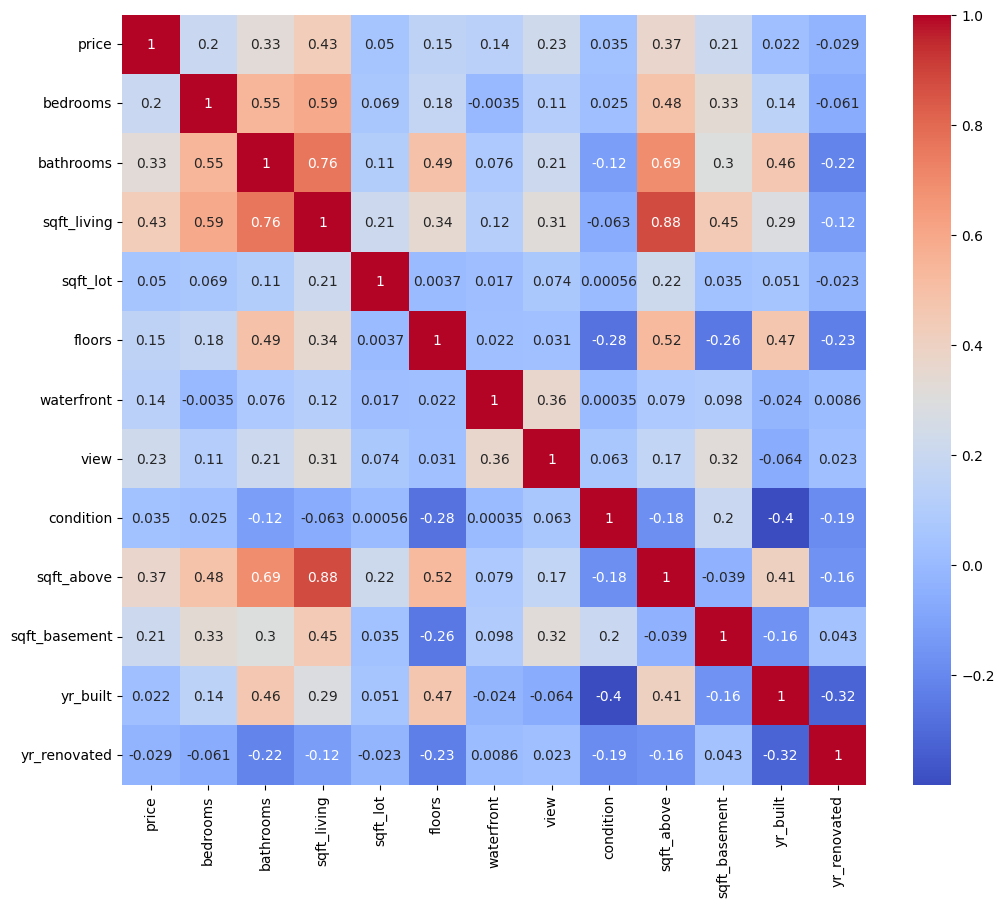

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

Q8. (Feature Identification) Clearly define: Independent Features X — input features Dependent Feature (y) — continuous target variable you want to predict Justify your selection with reasoning.

In [ ]:
# Independent Features (X):-
# date
# bedrooms
# bathrooms
# sqft_living
# sqft_lot
# floors
# waterfront
# view
# condition
# sqft_above
# sqft_basement
# yr_built
# yr_renovated
# street
# city
# statezip
# country

# Dependent Feature (y):-
# price

Q9. (Encoding Categorical Variables) Convert all categorical columns to numeric form using suitable encoding techniques (One-Hot Encoding). Show before and after transformation for at least two columns. Explain your encoding choices.

Before Encoding

In [53]:
print("------Before Encoding------\n")
print(df[["city","country"]].head())

------Before Encoding------

        city country
0  Shoreline     USA
1    Seattle     USA
2       Kent     USA
3   Bellevue     USA
4    Redmond     USA


One-Hot Encoding

In [44]:
df_encoded = pd.get_dummies(df,
                            columns=["city","country","statezip","street"],
                            drop_first=True)

After Encoding

In [49]:
print("________________________________ After Encoding ________________________________\n ")
print(df_encoded.head())

________________________________ After Encoding ________________________________
 
                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  ...  street_Indian Trail  \
0     1.5           0     0          3  ...                False   
1     2.0           0     4          5  ...                False   
2     1.0           0     0          4  ...                False   
3     1.0           0     0          4  ...                False   
4     1.0           0     0          4  ...                False   

   street_Nuthatch Tr

Q10. (Feature Scaling) Apply Standard Scaling on the independent features using StandardScaler. Show the first 5 rows of the scaled features.

In [65]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = df_encoded.drop("price", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

   bedrooms  bathrooms  sqft_living  sqft_lot    floors  waterfront      view  \
0 -0.441122  -0.843204    -0.829759 -0.193434 -0.022416   -0.085004 -0.309194   
1  1.759705   0.432802     1.568858 -0.161718  0.906555   -0.085004  4.830079   
2 -0.441122  -0.205201    -0.217125 -0.080978 -0.951388   -0.085004 -0.309194   
3 -0.441122   0.113800    -0.144440 -0.190145 -0.951388   -0.085004 -0.309194   
4  0.659291   0.432802    -0.206741 -0.121306 -0.951388   -0.085004 -0.309194   

   condition  sqft_above  sqft_basement  ...  statezip_WA 98155  \
0  -0.667112   -0.565224      -0.672464  ...          -0.139655   
1   2.286416    1.789559      -0.069128  ...          -0.139655   
2   0.809652    0.119171      -0.672464  ...          -0.139655   
3   0.809652   -0.959621       1.482306  ...          -0.139655   
4   0.809652   -0.797222       1.051352  ...          -0.139655   

   statezip_WA 98166  statezip_WA 98168  statezip_WA 98177  statezip_WA 98178  \
0          -0.113986         